In [1]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import json


## Get Information

In [6]:
url = "http://10.43.101.108/data"
groups = [3,4,5,6,7,8,9,10,1,2]


folder = "./data/"
failed_captured = []

os.makedirs(folder, exist_ok=True)

for group in groups:
    try:
        params = {
        "group_number": group,
        "day": "Tuesday"
        #"day": "Wednesday"    
        }
        response = requests.get(url, params=params)
        response.raise_for_status()  # Raises HTTPError for bad responses
        res = response.json()

         # Guardar JSON en archivo
        filename = os.path.join(folder, f"group_{group}_data.json")
        with open(filename, "w", encoding="utf-8") as f:
            json.dump(res, f, ensure_ascii=False, indent=4)
        print(f'Success to get data from group {group}. This file will be save in {filename} ')
        
    except requests.exceptions.RequestException as e:
        failed_captured.append(group)
        print(f"Request failed: {e}")

Request failed: 400 Client Error: Bad Request for url: http://10.43.101.108/data?group_number=3&day=Tuesday
Success to get data from group 4. This file will be save in ./data/group_4_data.json 
Success to get data from group 5. This file will be save in ./data/group_5_data.json 
Success to get data from group 6. This file will be save in ./data/group_6_data.json 
Success to get data from group 7. This file will be save in ./data/group_7_data.json 
Success to get data from group 8. This file will be save in ./data/group_8_data.json 
Success to get data from group 9. This file will be save in ./data/group_9_data.json 
Success to get data from group 10. This file will be save in ./data/group_10_data.json 
Request failed: 400 Client Error: Bad Request for url: http://10.43.101.108/data?group_number=11&day=Tuesday
Request failed: 400 Client Error: Bad Request for url: http://10.43.101.108/data?group_number=12&day=Tuesday
Request failed: 400 Client Error: Bad Request for url: http://10.43.10

### Validacion Base de datos

In [6]:
import sys
#print(sys.executable)

#!{sys.executable} -m pip show import sys

import subprocess

python_bin = sys.executable

# Comando para instalar pip en el Python del kernel
subprocess.run([python_bin, "-m", "ensurepip", "--upgrade"])
subprocess.run([python_bin, "-m", "pip", "install", "--upgrade", "pip"])

!{sys.executable} -m pip install psycopg2-binary

Looking in links: /tmp/tmp5pohg3mk
Processing /tmp/tmp5pohg3mk/pip-25.0.1-py3-none-any.whl
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 38.4 MB/s eta 0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 25.0.1
    Uninstalling pip-25.0.1:
      Successfully uninstalled pip-25.0.1
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 27.6 MB/s eta 0:00:00


In [8]:
import psycopg2

DB_CONFIG = {
    'host': '10.43.101.166',  # IP donde corre socat
    'port': 5433,             # Puerto donde socat escucha
    'database': 'rawdata',
    'user': 'admin',
    'password': 'admin'
}

try:
    conn = psycopg2.connect(**DB_CONFIG)
    print("Conexión exitosa a PostgreSQL")
    conn.close()
except Exception as e:
    print(f"Error al conectar: {e}")

Conexión exitosa a PostgreSQL


### Crear bases de datos

In [9]:
# Validar estructura

import os
import json

# Ruta a la carpeta
carpeta = "./data"

# Recorremos todos los archivos .json
for nombre_archivo in os.listdir(carpeta):
    if nombre_archivo.endswith(".json"):
        ruta_completa = os.path.join(carpeta, nombre_archivo)
        try:
            with open(ruta_completa, "r", encoding="utf-8") as f:
                json_data = json.load(f)

                # Entrar a la llave 'data'
                tabla = json_data.get("data", [])
                
                if isinstance(tabla, list) and len(tabla) > 0 and isinstance(tabla[0], dict):
                    columnas = list(tabla[0].keys())
                else:
                    columnas = "Formato no reconocido o 'data' vacía"

                print(f"{nombre_archivo}: {columnas}")
        except Exception as e:
            print(f"Error al procesar {nombre_archivo}: {e}")


group_7_data.json: ['brokered_by', 'status', 'price', 'bed', 'bath', 'acre_lot', 'street', 'city', 'state', 'zip_code', 'house_size', 'prev_sold_date']
Error al procesar group_3_data.json: Expecting value: line 1 column 1 (char 0)
group_10_data.json: ['brokered_by', 'status', 'price', 'bed', 'bath', 'acre_lot', 'street', 'city', 'state', 'zip_code', 'house_size', 'prev_sold_date']
group_5_data.json: ['brokered_by', 'status', 'price', 'bed', 'bath', 'acre_lot', 'street', 'city', 'state', 'zip_code', 'house_size', 'prev_sold_date']
group_4_data.json: ['brokered_by', 'status', 'price', 'bed', 'bath', 'acre_lot', 'street', 'city', 'state', 'zip_code', 'house_size', 'prev_sold_date']
group_2_data.json: ['brokered_by', 'status', 'price', 'bed', 'bath', 'acre_lot', 'street', 'city', 'state', 'zip_code', 'house_size', 'prev_sold_date']
group_1_data.json: ['brokered_by', 'status', 'price', 'bed', 'bath', 'acre_lot', 'street', 'city', 'state', 'zip_code', 'house_size', 'prev_sold_date']
group_9_

### Lectura datos

In [10]:
filename = './data/group_1_data.json'

with open(filename, 'r', encoding='utf-8') as f:
    json_file = json.load(f)

tabla_json = json_file.get("data", [])

In [ ]:
#!pip uninstall pandas -y -q
#!pip install pandas --upgrade -q

In [12]:
df = pd.DataFrame(tabla_json)

### Preprocesamiento

#### Exploracion

In [14]:
df.columns

Index(['brokered_by', 'status', 'price', 'bed', 'bath', 'acre_lot', 'street',
       'city', 'state', 'zip_code', 'house_size', 'prev_sold_date'],
      dtype='object')

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 73784 entries, 0 to 73783
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   brokered_by     73784 non-null  float64
 1   status          73784 non-null  object 
 2   price           73784 non-null  float64
 3   bed             73784 non-null  float64
 4   bath            73784 non-null  float64
 5   acre_lot        73784 non-null  float64
 6   street          73784 non-null  float64
 7   city            73784 non-null  object 
 8   state           73784 non-null  object 
 9   zip_code        73784 non-null  float64
 10  house_size      73784 non-null  float64
 11  prev_sold_date  73784 non-null  object 
dtypes: float64(8), object(4)
memory usage: 6.8+ MB


In [34]:
df.head()

,brokered_by,status,price,bed,bath,acre_lot,street,city,state,zip_code,house_size,prev_sold_date
0,101640.0,for_sale,289900.0,4.0,2.0,0.38,1758218.0,East Windsor,Connecticut,6016.0,1617.0,1999-09-30
1,107951.0,for_sale,299900.0,3.0,2.0,0.87,1336295.0,Vernon,Connecticut,6066.0,1850.0,2015-11-09
2,80935.0,for_sale,299000.0,3.0,2.0,0.35,920059.0,North Canaan,Connecticut,6018.0,1620.0,2011-08-23
3,33714.0,for_sale,221000.0,4.0,2.0,0.32,731702.0,Windsor Locks,Connecticut,6096.0,1735.0,2014-03-03
4,29997.0,for_sale,175000.0,3.0,2.0,0.19,1382878.0,Winchester,Connecticut,6098.0,2005.0,2007-07-19


In [67]:
y = df['price'].copy()

cat_cols = ['brokered_by','city', 'state', 'zip_code']
num_ccols = ['bed', 'bath', 'acre_lot','prev_sold_date', 'house_size']

In [68]:
# La variable status no genera valor
# Se debe eliminar street

# LAs columnas city, brokered_by, state y zip_code se transforman

for i in cat_cols:
    print(i)
    print(len(df[i].unique()))
    print(df[i].value_counts())
    print()

brokered_by
20856
brokered_by
22611.0    1046
53016.0     585
33714.0     407
79221.0     391
30807.0     330
           ... 
81951.0       1
3058.0        1
15552.0       1
88704.0       1
21688.0       1
Name: count, Length: 20856, dtype: int64

city
7747
city
Houston         1112
Cleveland        732
San Antonio      644
Indianapolis     592
Chicago          457
                ... 
Cadwell            1
McRae Helena       1
Wadley             1
Soperton           1
Ketchikan          1
Name: count, Length: 7747, dtype: int64

state
50
state
Texas                   7645
Ohio                    6239
Pennsylvania            4378
Georgia                 4271
Illinois                4218
New York                4131
Florida                 3814
Minnesota               2925
Michigan                2622
Oklahoma                2572
Missouri                2248
Louisiana               2068
Indiana                 1992
Arkansas                1880
Kentucky                1849
North Carolina 

#### Raw Functions

In [57]:
# Calcular el número de veces que aparece cada valor de 'brokered_by'
brokered = df['brokered_by'].value_counts().reset_index()
brokered.columns = ['brokered_by', 'count']  # Renombrar columnas

# Función que categoriza según el número de ocurrencias
def brokered_categories(row):
    i = row['count']
    if i <= 20:
        return 'agent'
    elif i <= 100:
        return 'retail'
    elif i <= 500:
        return 'wholesaler'
    else:
        return 'corporate'

# Aplicar la función a cada fila
brokered['category'] = brokered.apply(brokered_categories, axis=1)
brokered = brokered[['brokered_by','category']]


In [ ]:
brokered

In [59]:
bought_streets = df[['zip_code','prev_sold_date']]
bought_streets['prev_sold_date'] = pd.to_datetime(bought_streets['prev_sold_date'])
bought_streets['sold_year'] = bought_streets['prev_sold_date'].dt.year
grouped_bought_streets = bought_streets.groupby(['zip_code'])['sold_year'].count()\
    .reset_index(name='num_prev_sales')\
    .sort_values('num_prev_sales')

# Función que categoriza según el número de ocurrencias
def grouped_bought_categories(row):
    i = row['num_prev_sales']
    if i <= 10:
        return 'low_transactionality_zone'
    elif i <= 10:
        return 'mid-low_transactionality_zone'
    elif i <= 50:
        return 'mid_transactionality_zone'
    elif i <= 80:
        return 'mid-high_transactionality_zone'
    else:
        return 'high_transactionality_zone'

grouped_bought_streets['category'] = grouped_bought_streets.apply(grouped_bought_categories, axis=1)
grouped_bought_streets = grouped_bought_streets[['zip_code','category']]

/tmp/ipykernel_85/1116070154.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  bought_streets['prev_sold_date'] = pd.to_datetime(bought_streets['prev_sold_date'])
/tmp/ipykernel_85/1116070154.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  bought_streets['sold_year'] = bought_streets['prev_sold_date'].dt.year


In [ ]:
grouped_bought_streets

In [64]:
# Calcular el número de veces que aparece cada valor de 'brokered_by'
cities = df['city'].value_counts().reset_index()
cities.columns = ['city', 'count']  # Renombrar columnas

# Función que categoriza según el número de ocurrencias
def cities_categories(row):
    i = row['count']
    if i <= 50:
        return 'cities-low-demand'
    elif i <= 100:
        return 'cities-midlow-demand'
    elif i <= 500:
        return 'cities-mid-demand'
    else:
        return 'cities-high-demand'

# Aplicar la función a cada fila
cities['category'] = cities.apply(cities_categories, axis=1)
cities = cities[['city','category']]

In [65]:
cities

,city,category
0,Houston,cities-high-demand
1,Cleveland,cities-high-demand
2,San Antonio,cities-high-demand
3,Indianapolis,cities-high-demand
4,Chicago,cities-mid-demand
...,...,...
7742,Cadwell,cities-low-demand
7743,McRae Helena,cities-low-demand
7744,Wadley,cities-low-demand
7745,Soperton,cities-low-demand


#### Optimized functions

In [73]:
def get_us_region(state):
    northeast = {'Maine', 'New Hampshire', 'Vermont', 'Massachusetts', 'Rhode Island', 'Connecticut',
                 'New York', 'New Jersey', 'Pennsylvania'}
    
    midwest = {'Ohio', 'Indiana', 'Illinois', 'Michigan', 'Wisconsin',
               'Minnesota', 'Iowa', 'Missouri', 'North Dakota', 'South Dakota', 'Nebraska', 'Kansas'}
    
    south = {'Delaware', 'Maryland', 'District of Columbia', 'Virginia', 'West Virginia',
             'North Carolina', 'South Carolina', 'Georgia', 'Florida',
             'Kentucky', 'Tennessee', 'Mississippi', 'Alabama',
             'Oklahoma', 'Texas', 'Arkansas', 'Louisiana'}
    
    west = {'Montana', 'Idaho', 'Wyoming', 'Colorado', 'New Mexico',
            'Arizona', 'Utah', 'Nevada', 'Washington', 'Oregon', 'California',
            'Alaska', 'Hawaii'}

    if state in northeast:
        return 'Northeast'
    elif state in midwest:
        return 'Midwest'
    elif state in south:
        return 'South'
    elif state in west:
        return 'West'
    else:
        return 'Unknown'

def categorize_cities_by_demand(df, city_col='city'):
    # Contar ocurrencias por ciudad
    cities = df[city_col].value_counts().reset_index()
    cities.columns = [city_col, 'count']

    # Función interna de categorización
    def cities_categories(row):
        i = row['count']
        if i <= 50:
            return 'cities-low-demand'
        elif i <= 100:
            return 'cities-midlow-demand'
        elif i <= 500:
            return 'cities-mid-demand'
        else:
            return 'cities-high-demand'

    # Aplicar la categoría
    cities['cities_by_demand'] = cities.apply(cities_categories, axis=1)

    # Devolver solo ciudad y categoría
    return cities[[city_col, 'cities_by_demand']]

def categorize_transactionality_by_zipcode(df, zip_col='zip_code', date_col='prev_sold_date'):
    # Extraer columnas necesarias
    bought_streets = df[[zip_col, date_col]].copy()
    bought_streets[date_col] = pd.to_datetime(bought_streets[date_col])
    bought_streets['sold_year'] = bought_streets[date_col].dt.year

    # Agrupar por código postal y contar ventas por año
    grouped = bought_streets.groupby(zip_col)['sold_year'].count()\
        .reset_index(name='num_prev_sales')\
        .sort_values('num_prev_sales')

    # Función interna de categorización
    def grouped_bought_categories(row):
        i = row['num_prev_sales']
        if i <= 10:
            return 'low_transactionality_zone'
        elif i <= 30:
            return 'mid-low_transactionality_zone'
        elif i <= 50:
            return 'mid_transactionality_zone'
        elif i <= 80:
            return 'mid-high_transactionality_zone'
        else:
            return 'high_transactionality_zone'

    # Aplicar categorías
    grouped['zone_by_demand'] = grouped.apply(grouped_bought_categories, axis=1)

    # Retornar solo zip y categoría
    return grouped[[zip_col, 'zone_by_demand']]


def categorize_brokered_by_type(df, col='brokered_by'):
    # Contar ocurrencias
    brokered = df[col].value_counts().reset_index()
    brokered.columns = [col, 'count']

    # Función interna de categorización
    def brokered_categories(row):
        i = row['count']
        if i <= 20:
            return 'agent'
        elif i <= 100:
            return 'retail'
        elif i <= 500:
            return 'wholesaler'
        else:
            return 'corporate'

    # Aplicar categorías
    brokered['broker_type'] = brokered.apply(brokered_categories, axis=1)

    # Retornar solo columnas necesarias
    return brokered[[col, 'broker_type']]



#### Proprocess Cat columns

In [74]:
cities_parameters = categorize_cities_by_demand(df, city_col='city')
zipcode_parameters = categorize_transactionality_by_zipcode(df, zip_col='zip_code', date_col='prev_sold_date')
broker_parameters = categorize_brokered_by_type(df, col='brokered_by')



In [81]:
cities_parameters

,city,cities_by_demand
0,Houston,cities-high-demand
1,Cleveland,cities-high-demand
2,San Antonio,cities-high-demand
3,Indianapolis,cities-high-demand
4,Chicago,cities-mid-demand
...,...,...
7742,Cadwell,cities-low-demand
7743,McRae Helena,cities-low-demand
7744,Wadley,cities-low-demand
7745,Soperton,cities-low-demand


In [87]:
df_cat = df[cat_cols]
df_cat['region'] = df_cat['state'].apply(get_us_region)
df_cat = df_cat.merge(cities_parameters, how='left', on='city')
df_cat = df_cat.merge(zipcode_parameters, how='left', on='zip_code')
df_cat = df_cat.merge(broker_parameters, how='left', on='brokered_by')
df_cat.drop(columns=['brokered_by', 'city', 'state', 'zip_code'], inplace = True)


/tmp/ipykernel_85/1070687481.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cat['region'] = df_cat['state'].apply(get_us_region)


In [88]:
df_cat

,region,cities_by_demand,zone_by_demand,broker_type
0,Northeast,cities-low-demand,low_transactionality_zone,agent
1,Northeast,cities-low-demand,mid-low_transactionality_zone,agent
2,Northeast,cities-low-demand,low_transactionality_zone,agent
3,Northeast,cities-low-demand,low_transactionality_zone,wholesaler
4,Northeast,cities-midlow-demand,mid-low_transactionality_zone,agent
...,...,...,...,...
73779,West,cities-low-demand,low_transactionality_zone,agent
73780,West,cities-low-demand,low_transactionality_zone,agent
73781,West,cities-low-demand,low_transactionality_zone,agent
73782,West,cities-low-demand,low_transactionality_zone,agent


In [89]:
for i in df_cat.columns:
    print(i)
    print(len(df_cat[i].unique()))
    print(df_cat[i].value_counts())
    print()

region
4
region
South        34225
Midwest      25873
Northeast    10641
West          3045
Name: count, dtype: int64

cities_by_demand
4
cities_by_demand
cities-low-demand       43952
cities-mid-demand       16191
cities-midlow-demand    10561
cities-high-demand       3080
Name: count, dtype: int64

zone_by_demand
5
zone_by_demand
low_transactionality_zone         31981
mid-low_transactionality_zone     30195
mid_transactionality_zone          8140
mid-high_transactionality_zone     2383
high_transactionality_zone         1085
Name: count, dtype: int64

broker_type
4
broker_type
agent         54225
retail        12865
wholesaler     5063
corporate      1631
Name: count, dtype: int64



#### Preprocess Num columns

bed


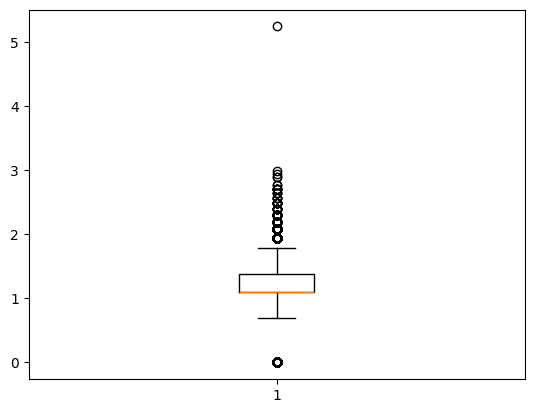

bath


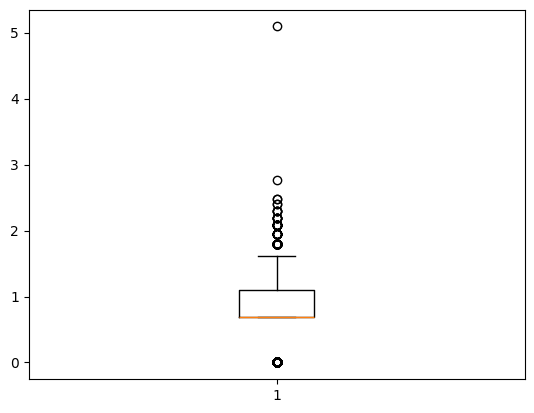

acre_lot


/jupyter_app/.venv/lib/python3.12/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


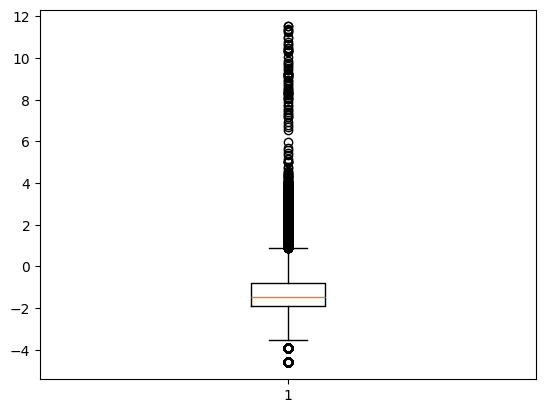

house_size


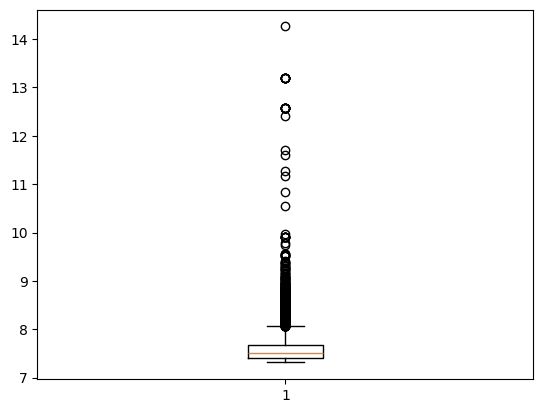

In [98]:
df_num = df[num_cols]

for i in df_num.columns:
    print(i)
    plt.boxplot(np.log(df_num[i]))
    plt.show()

In [104]:
print(df_num.isna().sum())

df_num.describe()

bed           0
bath          0
acre_lot      0
house_size    0
dtype: int64


,bed,bath,acre_lot,house_size
count,73784.000000,73784.000000,73784.000000,7.378400e+04
mean,3.433183,2.262604,18.644386,2.109465e+03
std,1.122195,0.904863,977.809958,8.693199e+03
min,1.000000,1.000000,0.000000,1.500000e+03
25%,3.000000,2.000000,0.150000,1.646000e+03
50%,3.000000,2.000000,0.230000,1.837000e+03
75%,4.000000,3.000000,0.460000,2.150000e+03
max,190.000000,163.000000,100000.000000,1.560780e+06


In [99]:
df_num.corr()

,bed,bath,acre_lot,house_size
bed,1.000000,0.577265,0.009075,0.029943
bath,0.577265,1.000000,0.003170,0.035928
acre_lot,0.009075,0.003170,1.000000,-0.000007
house_size,0.029943,0.035928,-0.000007,1.000000


In [101]:
(df['bath']/df['bed']).describe()

count    73784.000000
mean         0.685257
std          0.230609
min          0.083333
25%          0.500000
50%          0.666667
75%          0.750000
max          4.000000
dtype: float64

In [102]:
(df['house_size']/df['acre_lot']).describe()

/jupyter_app/.venv/lib/python3.12/site-packages/pandas/core/nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


count    7.378400e+04
mean              inf
std               NaN
min      1.664000e-02
25%      4.300000e+03
50%      8.120294e+03
75%      1.281571e+04
max               inf
dtype: float64

In [122]:
df_num = df[num_cols].copy()

# Calcular tasa antes del log
df_num['rate_bath_bed'] = df['bath'] / df['bed']

# Eliminar columnas innecesarias
df_num = df_num.drop(columns=['bed', 'bath'], errors='ignore')

# Reemplazar ceros o negativos antes de log (solo columnas relevantes)
df_num = df_num.applymap(lambda x: np.nan if x <= 0 else x)

# Aplicar log
df_num = np.log(df_num)

# Imputar NaN resultantes (por log de 0 o valores negativos)
df_num = df_num.fillna(df_num.median(numeric_only=True))


/tmp/ipykernel_85/3287143694.py:10: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_num = df_num.applymap(lambda x: np.nan if x <= 0 else x)


In [124]:
df_num.describe()

,acre_lot,house_size,rate_bath_bed
count,73784.000000,73784.000000,73784.000000
mean,-1.250982,7.568741,-0.433511
std,1.149201,0.233966,0.339157
min,-4.605170,7.313220,-2.484907
25%,-1.897120,7.406103,-0.693147
50%,-1.469676,7.515889,-0.405465
75%,-0.776529,7.673223,-0.287682
max,11.512925,14.260696,1.386294


## Pipeline

In [127]:
y = df['price'].copy()

cat_cols = ['brokered_by','city', 'state', 'zip_code']
num_cols = ['bed', 'bath', 'acre_lot','house_size']
date_cols = ['prev_sold_date']

def get_us_region(state):
    northeast = {'Maine', 'New Hampshire', 'Vermont', 'Massachusetts', 'Rhode Island', 'Connecticut',
                 'New York', 'New Jersey', 'Pennsylvania'}
    
    midwest = {'Ohio', 'Indiana', 'Illinois', 'Michigan', 'Wisconsin',
               'Minnesota', 'Iowa', 'Missouri', 'North Dakota', 'South Dakota', 'Nebraska', 'Kansas'}
    
    south = {'Delaware', 'Maryland', 'District of Columbia', 'Virginia', 'West Virginia',
             'North Carolina', 'South Carolina', 'Georgia', 'Florida',
             'Kentucky', 'Tennessee', 'Mississippi', 'Alabama',
             'Oklahoma', 'Texas', 'Arkansas', 'Louisiana'}
    
    west = {'Montana', 'Idaho', 'Wyoming', 'Colorado', 'New Mexico',
            'Arizona', 'Utah', 'Nevada', 'Washington', 'Oregon', 'California',
            'Alaska', 'Hawaii'}

    if state in northeast:
        return 'Northeast'
    elif state in midwest:
        return 'Midwest'
    elif state in south:
        return 'South'
    elif state in west:
        return 'West'
    else:
        return 'Unknown'

def categorize_cities_by_demand(df, city_col='city'):
    # Contar ocurrencias por ciudad
    cities = df[city_col].value_counts().reset_index()
    cities.columns = [city_col, 'count']

    # Función interna de categorización
    def cities_categories(row):
        i = row['count']
        if i <= 50:
            return 'cities-low-demand'
        elif i <= 100:
            return 'cities-midlow-demand'
        elif i <= 500:
            return 'cities-mid-demand'
        else:
            return 'cities-high-demand'

    # Aplicar la categoría
    cities['cities_by_demand'] = cities.apply(cities_categories, axis=1)

    # Devolver solo ciudad y categoría
    return cities[[city_col, 'cities_by_demand']]

def categorize_transactionality_by_zipcode(df, zip_col='zip_code', date_col='prev_sold_date'):
    # Extraer columnas necesarias
    bought_streets = df[[zip_col, date_col]].copy()
    bought_streets[date_col] = pd.to_datetime(bought_streets[date_col])
    bought_streets['sold_year'] = bought_streets[date_col].dt.year

    # Agrupar por código postal y contar ventas por año
    grouped = bought_streets.groupby(zip_col)['sold_year'].count()\
        .reset_index(name='num_prev_sales')\
        .sort_values('num_prev_sales')

    # Función interna de categorización
    def grouped_bought_categories(row):
        i = row['num_prev_sales']
        if i <= 10:
            return 'low_transactionality_zone'
        elif i <= 30:
            return 'mid-low_transactionality_zone'
        elif i <= 50:
            return 'mid_transactionality_zone'
        elif i <= 80:
            return 'mid-high_transactionality_zone'
        else:
            return 'high_transactionality_zone'

    # Aplicar categorías
    grouped['zone_by_demand'] = grouped.apply(grouped_bought_categories, axis=1)

    # Retornar solo zip y categoría
    return grouped[[zip_col, 'zone_by_demand']]


def categorize_brokered_by_type(df, col='brokered_by'):
    # Contar ocurrencias
    brokered = df[col].value_counts().reset_index()
    brokered.columns = [col, 'count']

    # Función interna de categorización
    def brokered_categories(row):
        i = row['count']
        if i <= 20:
            return 'agent'
        elif i <= 100:
            return 'retail'
        elif i <= 500:
            return 'wholesaler'
        else:
            return 'corporate'

    # Aplicar categorías
    brokered['broker_type'] = brokered.apply(brokered_categories, axis=1)

    # Retornar solo columnas necesarias
    return brokered[[col, 'broker_type']]

cities_parameters = categorize_cities_by_demand(df, city_col='city')
zipcode_parameters = categorize_transactionality_by_zipcode(df, zip_col='zip_code', date_col='prev_sold_date')
broker_parameters = categorize_brokered_by_type(df, col='brokered_by')

df_cat = df[cat_cols].copy()
df_cat['region'] = df_cat['state'].apply(get_us_region)
df_cat = df_cat.merge(cities_parameters, how='left', on='city')
df_cat = df_cat.merge(zipcode_parameters, how='left', on='zip_code')
df_cat = df_cat.merge(broker_parameters, how='left', on='brokered_by')
df_cat.drop(columns=['brokered_by', 'city', 'state', 'zip_code'], inplace = True)

df_cat_encoded = pd.get_dummies(df_cat, drop_first=True).astype(int)

df_num = df[num_cols].copy()
# Calcular tasa antes del log
df_num['rate_bath_bed'] = df['bath'] / df['bed']
# Eliminar columnas innecesarias
df_num = df_num.drop(columns=['bed', 'bath'], errors='ignore')
# Reemplazar ceros o negativos antes de log (solo columnas relevantes)
df_num = df_num.applymap(lambda x: np.nan if x <= 0 else x)
# Aplicar log
df_num = np.log(df_num)
# Imputar NaN resultantes (por log de 0 o valores negativos)
df_num = df_num.fillna(df_num.median(numeric_only=True))

from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df_num_scaled = pd.DataFrame(scaler.fit_transform(df_num), columns=df_num.columns, index=df_num.index)

procesed_df = pd.concat([df_num_scaled, df_cat_encoded], axis=1)
procesed_df['target'] = y.values



/tmp/ipykernel_85/1365101307.py:127: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  df_num = df_num.applymap(lambda x: np.nan if x <= 0 else x)


In [128]:
procesed_df

,acre_lot,house_size,rate_bath_bed,region_Northeast,region_South,region_West,cities_by_demand_cities-low-demand,cities_by_demand_cities-mid-demand,cities_by_demand_cities-midlow-demand,zone_by_demand_low_transactionality_zone,zone_by_demand_mid-high_transactionality_zone,zone_by_demand_mid-low_transactionality_zone,zone_by_demand_mid_transactionality_zone,broker_type_corporate,broker_type_retail,broker_type_wholesaler,target
0,0.225683,0.010811,0.462843,1,0,0,1,0,0,1,0,0,0,0,0,0,289900.0
1,0.277074,0.030187,0.537157,1,0,0,1,0,0,0,0,1,0,0,0,0,299900.0
2,0.220581,0.011078,0.537157,1,0,0,1,0,0,1,0,0,0,0,0,0,299000.0
3,0.215021,0.020949,0.462843,1,0,0,1,0,0,1,0,0,0,0,0,1,221000.0
4,0.182679,0.041768,0.537157,1,0,0,0,0,1,0,0,1,0,0,0,0,175000.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
73779,0.331746,0.025682,0.462843,0,0,1,1,0,0,1,0,0,0,0,0,0,220000.0
73780,0.280541,0.021363,0.537157,0,0,1,1,0,0,1,0,0,0,0,0,0,289900.0
73781,0.355909,0.003975,0.641896,0,0,1,1,0,0,1,0,0,0,0,0,0,225000.0
73782,0.325536,0.061775,0.567582,0,0,1,1,0,0,1,0,0,0,0,0,0,300000.0


In [129]:
procesed_df.columns

Index(['acre_lot', 'house_size', 'rate_bath_bed', 'region_Northeast',
       'region_South', 'region_West', 'cities_by_demand_cities-low-demand',
       'cities_by_demand_cities-mid-demand',
       'cities_by_demand_cities-midlow-demand',
       'zone_by_demand_low_transactionality_zone',
       'zone_by_demand_mid-high_transactionality_zone',
       'zone_by_demand_mid-low_transactionality_zone',
       'zone_by_demand_mid_transactionality_zone', 'broker_type_corporate',
       'broker_type_retail', 'broker_type_wholesaler', 'target'],
      dtype='object')